## Load Data

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv
/kaggle/input/datasets/mamtapathak/superstore-datasets/sample superstore.xls


In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('/kaggle/input/datasets/mamtapathak/superstore-datasets/Sample - Superstore.csv', encoding = 'latin1')

In [4]:
df.head(10)
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Data Cleaning & Column Selection
Selecting only relevant columns for customer-level analysis.

In [5]:
# check columns names

df.shape
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
#column selection 

df = df[['Customer ID', 'Order ID', 'Sales', 'Profit', 'Discount', 'Order Date']]

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Customer ID  9994 non-null   object 
 1   Order ID     9994 non-null   object 
 2   Sales        9994 non-null   float64
 3   Profit       9994 non-null   float64
 4   Discount     9994 non-null   float64
 5   Order Date   9994 non-null   object 
dtypes: float64(3), object(3)
memory usage: 468.6+ KB


In [8]:
df.columns

Index(['Customer ID', 'Order ID', 'Sales', 'Profit', 'Discount', 'Order Date'], dtype='object')

## Build Customer-Level Data 

In [9]:
# Convert transaction data → customer behavior data
# measuring Customers - how much they spend(sales), how profitable they are
# how often they buy, how price-sensitive they are
# agg - combine multiple rows into summary values
# reset_index() = clean structure back to table format


customer_df = df.groupby('Customer ID').agg({'Sales':'sum',
                                            'Profit':'sum',
                                            'Order ID':'count',
                                            'Discount':'mean'
                                            }).reset_index()

In [10]:
# Rename columns

customer_df.columns = [
    'Customer ID',
    'Total Sales',
    'Total Profit',
    'Order Count',
    'Avg Discount'
]

In [11]:
customer_df.head()

,Customer ID,Total Sales,Total Profit,Order Count,Avg Discount
0,AA-10315,5563.560,-362.8825,11,0.090909
1,AA-10375,1056.390,277.3824,15,0.080000
2,AA-10480,1790.512,435.8274,12,0.016667
3,AA-10645,5086.935,857.8033,18,0.063889
4,AB-10015,886.156,129.3465,6,0.066667


## Prepare for clustering 

We convert customer data into a format ML can understand.


In [12]:
# keeping only behavior numbers - 
# clustering uses only numbers - no mix - AA-10375

features = customer_df[['Total Sales', 'Total Profit', 'Order Count', 'Avg Discount']]

In [13]:
# scale the data - Making all numbers in data same range.
# clustering depends on distance between customers
# fit - learns pattern for data , transform - applies d learned rule to convert data 
# scaler.fit_transform - learn how to scale → then apply scaling immediately
# learn + change in one step


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Cluster

In [14]:
# Find optimal number of clusters 
# Elbow Method 
# how many customer groups exist in the data

# import tools

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [15]:
# Create empty list

wcss = []

In [16]:
# Test cluster sizes (1 to 10)

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

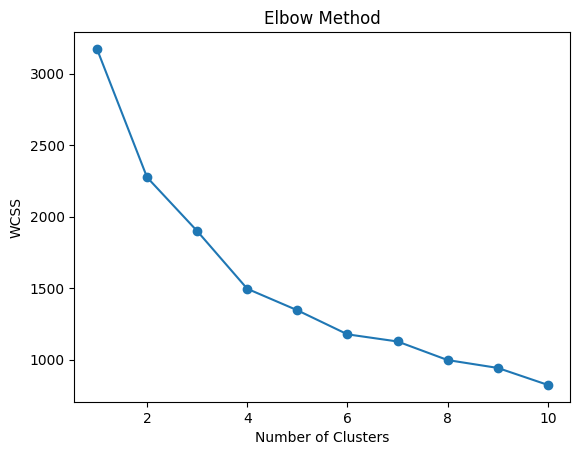

In [17]:
# plot result 

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [18]:
# lock the final number of clusters and build the model.
# n_clusters=4 - where d first flattening starts 

kmeans = KMeans(n_clusters=4, random_state=42)
customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

In [19]:
customer_df.head()

,Customer ID,Total Sales,Total Profit,Order Count,Avg Discount,Cluster
0,AA-10315,5563.560,-362.8825,11,0.090909,3
1,AA-10375,1056.390,277.3824,15,0.080000,3
2,AA-10480,1790.512,435.8274,12,0.016667,3
3,AA-10645,5086.935,857.8033,18,0.063889,0
4,AB-10015,886.156,129.3465,6,0.066667,3


## Cluster Meaning 

In [20]:
# first check cluster averages 
# Each cluster = type of customer behavior
# who brings profit, who is risky (discount dependent), who buys often, who depends on discount 



customer_df.groupby('Cluster')[['Total Sales','Total Profit','Order Count','Avg Discount']].mean()

,Total Sales,Total Profit,Order Count,Avg Discount
Cluster,,,,
0,4214.811215,456.351839,19.394495,0.159879
1,1682.674702,-118.911845,9.306306,0.253265
2,9930.505107,2480.280804,17.891304,0.106932
3,1785.065136,323.185125,9.371336,0.094090


## Cluster Interpretation

* Cluster 2- VIP / High-Value Customers
* Cluster 0 - Loyal Regular Customers
* Cluster 3 - Low-Value Customers
* Cluster 1 - Discount-Dependent / Loss Customers

## 2D visualization 

In [21]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [22]:
# PCA transformation

pca = PCA(n_components=2)
components = pca.fit_transform(scaled_features)

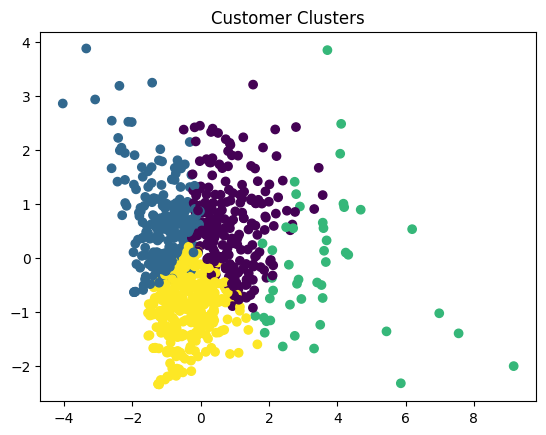

In [23]:
# plot clusters 

plt.scatter(components[:,0], components[:,1], c=customer_df['Cluster'])
plt.title("Customer Clusters")
plt.show()

# Key Insights

- VIP customers (Cluster 2) drive most revenue and profit
- Cluster 1 is loss-making due to high discount usage
- Majority of customers are low-to-mid value contributors
- Profit is concentrated in a small customer group

# Recommendations

- Retain VIP customers with loyalty programs
- Reduce excessive discounting for loss-making segment
- Target marketing on mid-value customers to increase conversion
- Avoid over-investing in low-value customers

# Conclusion

Customer segmentation reveals that revenue is driven by a small high-value group, while discount-heavy customers reduce overall profitability.